> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API
%pip install -q coptpy


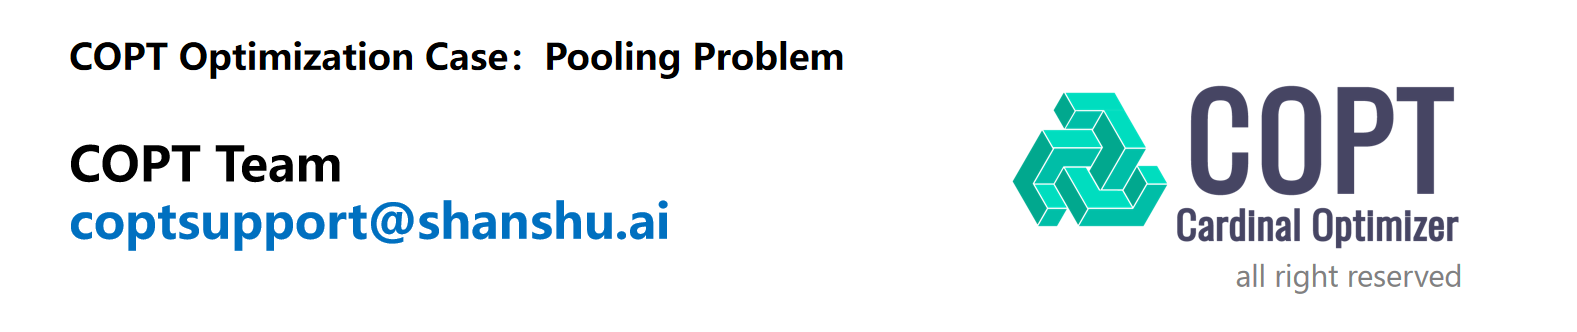

# Pooling Problem Code Implementation
## Steps to Model and Solve the Pooling Problem Using COPT

1. **Import the COPT-Python interface library** `coptpy`

2. **Add Model Data**

3. **Create the COPT solver environment and model**

4. **Build the model: sequentially add the three key components**
   - **Decision variables**:
     - $f_{ij}$: transportation flow on route $(i,j)$, $f_{ij} \geq 0$;
     - $w_{i}$: sulfur content of the gas leaving node $i$;
   - **Objective function**: Maximize operating profit;
   - **Constraints**:
     - The total amount of natural gas leaving source $i$ cannot exceed its maximum supply $ss_i$;
     - The total amount of natural gas received by terminal $i$ must be at least its minimum demand $td_i$;
     - A pool neither produces nor consumes natural gas. Its inflow equals its outflow;
     - The linear-blending quality-conservation constraint determines the sulfur content $w_i$ of the gas leaving node $i$ from the sulfur contents $w_j$, $j \in NODE_i^{in}$, of all gas entering the node, weighted by flow $f_{ji}$.

5. **Solve**

6. View and analyze **results**

## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT

## Add Model Data

In [6]:
# Add all nodes
SOURCE = ["S1", "S2", "S3"]
POOL = ["P1", "P2"]
TERMINAL = ["T1", "T2", "T3", "T4", "T5"]
NODE = SOURCE + POOL + TERMINAL

# Add material-transportation routes between nodes
source_to_pool = [(s, p) for s in SOURCE for p in POOL]
source_to_terminal = [(s, t) for s in SOURCE for t in TERMINAL]
pool_to_terminal = [(p, t) for p in POOL for t in TERMINAL]
ROUTE = source_to_pool + source_to_terminal + pool_to_terminal

# Add supply, demand, quality, cost, and price data
S_SUPPLY = {"S1":200, "S2":400, "S3":200}
S_QUALITY = {"S1":0.03, "S2":0.05, "S3":0.01}
S_COST = {"S1":5, "S2":3.5, "S3":8}
T_DEMAND = {"T1":100, "T2":80, "T3":160, "T4":90, "T5":120}
T_QUALITY = {"T1":0.038, "T2":0.03, "T3":0.04, "T4":0.02, "T5":0.015}
T_PRICE = {"T1":6.20, "T2":7.09, "T3":5.88, "T4":10.34, "T5":12.71}
R_COST = dict()
for r in ROUTE:
    if r in source_to_pool:
        R_COST[r] = 0.35
    elif r in source_to_terminal:
        R_COST[r] = 0.76
    else:
        R_COST[r] = 0.28

# Add upstream and downstream nodes for each node
NODE_IN = dict()
NODE_OUT = dict()
for i in NODE:
    if i in SOURCE:
        NODE_IN[i] = []
        NODE_OUT[i] = POOL + TERMINAL
    elif i in POOL:
        NODE_IN[i] = SOURCE
        NODE_OUT[i] = TERMINAL
    elif i in TERMINAL:
        NODE_IN[i] = POOL + SOURCE
        NODE_OUT[i] = []

## Create the COPT Environment and COPT Model

In [8]:
env = cp.Envr()
model_1 = env.createModel("standard_pooling_problem")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three components of COPT Model

### Add Decision Variables

- $f_{ij}$: transportation flow on route $(i,j)$, $f_{ij} \geq 0$;
- $w_i$: sulfur content of the gas leaving node $i$.

In [10]:
f = model_1.addVars(ROUTE, lb=0, ub=COPT.INFINITY, nameprefix="f")
w = model_1.addVars(NODE, lb=0, ub=COPT.INFINITY, nameprefix="w")

### Set Objective Function

The objective is to maximize operating profit, where profit $=$ sales revenue $-$ transportation cost $-$ supply cost:
$$
\max_{f_{ij},w_i}\quad \sum_{i \in TERMINAL} (tp_i \sum_{j \in NODE_i^{in}} f_{ji}) - \sum_{(i,j) \in ROUTE} f_{ij} rc_{ij} - \sum_{i \in SOURCE} (sc_i \sum_{j \in NODE_i^{out}} f_{ij})
$$

In [12]:
sale_income = cp.quicksum(cp.quicksum(T_PRICE[i] * f[(j, i)] for j in NODE_IN[i]) for i in TERMINAL)
trans_cost = cp.quicksum(f[(i, j)] * R_COST[(i, j)] for (i, j) in ROUTE)
supply_cost = cp.quicksum(cp.quicksum(S_COST[i] * f[(i, j)] for j in NODE_OUT[i]) for i in SOURCE)

obj_model_1 = sale_income - trans_cost - supply_cost
model_1.setObjective(obj_model_1, cp.COPT.MAXIMIZE)

### Add constraints

1. The total amount of natural gas leaving source $i$ cannot exceed its maximum supply $ss_i$:
$$
\sum_{j \in NODE_i^{out}} f_{ij} \leq ss_i ,\quad \forall i \in SOURCE
$$

In [15]:
model_1.addConstrs(cp.quicksum(f[(i, j)] for j in NODE_OUT[i]) <= S_SUPPLY[i] for i in SOURCE)

2. The total amount of natural gas received by terminal $i$ must be at least its minimum demand $td_i$:
$$
\sum_{j \in NODE_i^{in}} f_{ji} \geq td_i ,\quad \forall i \in TERMINAL
$$

In [17]:
model_1.addConstrs(cp.quicksum(f[(j, i)] for j in NODE_IN[i]) >= T_DEMAND[i] for i in TERMINAL)

3. A pool neither produces nor consumes natural gas. Its inflow equals its outflow:
$$
\sum_{j \in NODE_i^{in}} f_{ji} = \sum_{j \in NODE_i^{out}} f_{ij}, \quad \forall i \in POOL
$$

In [19]:
model_1.addConstrs(cp.quicksum(f[j, i] for j in NODE_IN[i]) == cp.quicksum(f[i, j] for j in NODE_OUT[i]) for i in POOL)

4. Under the linear blending model, sulfur-content conservation determines the sulfur content $w_i$ leaving node $i$ from the sulfur contents $w_j$ of all incoming materials, weighted by their flows $f_{ji}$. This is a bilinear constraint.

- A source has no upstream input and its sulfur content is known, so $w_i$ is fixed to the source sulfur content $sq_i$:
$$
w_i = sq_i ,\quad \forall i \in SOURCE
$$

In [21]:
model_1.addConstrs(w[i] == S_QUALITY[i] for i in SOURCE)

- The sulfur content $w_i$ leaving a pool is determined by all incoming flows and sulfur contents:
$$
\sum_{j \in NODE_i^{in}} f_{ji} w_j = w_i \sum_{j \in NODE_i^{in}} f_{ji} ,\quad \forall i \in POOL
$$

In [23]:
for i in POOL:
    model_1.addQConstr(cp.quicksum(f[(j, i)] * w[j] for j in NODE_IN[i]) == w[i] * cp.quicksum(f[(j, i)] for j in NODE_IN[i]))

- The sulfur content $w_i$ received by a terminal is determined by all incoming flows and sulfur contents and must not exceed the terminal limit $tq_i$:
$$
\sum_{j \in NODE_i^{in}} f_{ji} w_j = w_i \sum_{j \in NODE_i^{in}} f_{ji} ,\quad \forall i \in TERMINAL
$$
$$
w_i \leq tq_i ,\quad \forall i \in TERMINAL
$$

In [25]:
for i in TERMINAL:
    model_1.addQConstr(cp.quicksum(f[(j, i)] * w[j] for j in NODE_IN[i]) == w[i] * cp.quicksum(f[(j, i)] for j in NODE_IN[i]))
    model_1.addConstr(w[i] <= T_QUALITY[i])

## Solve

In [27]:
model_1.solve()

Model fingerprint: 3aeaae13

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing a QCP problem

The original problem has:
    18 rows, 41 columns and 70 non-zero elements
    7 quadratic constraints

The problem is identified as a non-convex QCP, finding local optimum

The presolved problem has:
    18 rows, 41 columns and 70 non-zero elements
    7 quadratic constraints

Starting NLP barrier solver using 4 threads

Iter     Objective            Compl       Primal.Inf         Dual.Inf       Time
   0  -7.92999207e-01  +3.99830001e+02  +1.59949999e+02  +4.71750000e+00   0.01s
   1  -1.27888098e+00  +3.96119088e+02  +1.59908662e+02  +4.59369386e+00   0.04s
   2  -1.64452170e+01  +3.93415343e+02  +1.58250557e+02  +2.50889309e+01   0.05s
   3  -5.50483840e+01  +3.85285228e+02  +1.55471204e+02  +4.75323744e+01   0.08s

## Retrieve Results

In [29]:
if model_1.status in (COPT.OPTIMAL, COPT.LOCAL_OPTIMAL):
    print("\nMaximum Profit:")
    print(" {0:.3e}".format(model_1.objval))
    print("\nVariable solution:")
    vars_model_3 = model_1.getVars()
    for var in vars_model_3:
        print(" {0} = {1:.3e}".format(var.name, var.x))
else:
  print("\n No solution available")


Maximum Profit:
 1.284e+03

Variable solution:
 f(S1,P1) = 1.455e+02
 f(S1,P2) = 5.454e+01
 f(S2,P1) = 1.698e+02
 f(S2,P2) = 1.828e-01
 f(S3,P1) = 6.274e+00
 f(S3,P2) = 1.937e+02
 f(S1,T1) = 0.000e+00
 f(S1,T2) = 0.000e+00
 f(S1,T3) = 0.000e+00
 f(S1,T4) = 0.000e+00
 f(S1,T5) = 0.000e+00
 f(S2,T1) = 0.000e+00
 f(S2,T2) = 0.000e+00
 f(S2,T3) = 0.000e+00
 f(S2,T4) = 0.000e+00
 f(S2,T5) = 0.000e+00
 f(S3,T1) = 0.000e+00
 f(S3,T2) = 0.000e+00
 f(S3,T3) = 0.000e+00
 f(S3,T4) = 0.000e+00
 f(S3,T5) = 0.000e+00
 f(P1,T1) = 9.157e+01
 f(P1,T2) = 4.840e+01
 f(P1,T3) = 1.589e+02
 f(P1,T4) = 1.950e+01
 f(P1,T5) = 3.154e+00
 f(P2,T1) = 8.434e+00
 f(P2,T2) = 3.160e+01
 f(P2,T3) = 1.069e+00
 f(P2,T4) = 7.050e+01
 f(P2,T5) = 1.368e+02
 w(S1) = 3.000e-02
 w(S2) = 5.000e-02
 w(S3) = 1.000e-02
 w(P1) = 4.017e-02
 w(P2) = 1.442e-02
 w(T1) = 3.800e-02
 w(T2) = 3.000e-02
 w(T3) = 4.000e-02
 w(T4) = 2.000e-02
 w(T5) = 1.500e-02


To make the model output easier to interpret, the route, flow, and cost results are summarized in a table, and a network diagram is drawn to visualize the routes actually used and their flow levels. In the network diagram, arrow width is proportional to route flow, making it easier to distinguish the scale of different routes.

In [31]:
# Print solution results
if model_1.status in (COPT.OPTIMAL, COPT.LOCAL_OPTIMAL):
    # Extract flow variables
    flow_value = {(i, j): float(f[(i, j)].x) for (i, j) in ROUTE}

    # Calculate sales revenue, transportation cost, and supply cost
    sale_income_value = sum(
        T_PRICE[t] * sum(flow_value[(j, t)] for j in NODE_IN[t])
        for t in TERMINAL
    )
    trans_cost_value = sum(flow_value[r] * R_COST[r] for r in ROUTE)
    supply_cost_value = sum(
        S_COST[s] * sum(flow_value[(s, j)] for j in NODE_OUT[s])
        for s in SOURCE
    )
    profit_value = sale_income_value - trans_cost_value - supply_cost_value

    print("-" * 68)
    print(f"Maximum profit: {profit_value:,.4f}")
    print(f"Sales revenue: {sale_income_value:,.4f}")
    print(f"Transportation cost: {trans_cost_value:,.4f}")
    print(f"Supply cost: {supply_cost_value:,.4f}")
    print("-" * 68)
else:
    print("-" * 68)
    print(f"No usable solution was obtained. Current solution status: {model_1.status}")
    print("\n" + "-" * 68)

# Print the table of active route flows
import pandas as pd

if model_1.status in (COPT.OPTIMAL, COPT.LOCAL_OPTIMAL):
    # Extract active routes with positive flow, ordered by index from 0 to 15
    route_df = pd.DataFrame([
        {
            "Upstream node": i,
            "Downstream node": j,
            "Route type": (
                "Source→Pool" if i in SOURCE and j in POOL
                else "Source→Terminal" if i in SOURCE and j in TERMINAL
                else "Pool→Terminal"
            ),
            "Transport flow": flow_value[(i, j)],
            "Unit transport cost": R_COST[(i, j)],
            "Transportation cost": flow_value[(i, j)] * R_COST[(i, j)],
        }
        for (i, j) in ROUTE if flow_value[(i, j)] > 1e-6
    ])

    print("\nActive route flow table: ")
    display(route_df.style.format({
        "Transport flow": "{:,.2f}",
        "Unit transport cost": "{:,.2f}",
        "Transportation cost": "{:,.2f}",
    }))

--------------------------------------------------------------------
Maximum profit: 1,283.9014
Sales revenue: 4,838.0021
Transportation cost: 359.1001
Supply cost: 3,195.0006
--------------------------------------------------------------------

Active route flow table: 


,Upstream node,Downstream node,Route type,Transport flow,Unit transport cost,Transportation cost
0,S1,P1,Source→Pool,145.46,0.35,50.91
1,S1,P2,Source→Pool,54.54,0.35,19.09
2,S2,P1,Source→Pool,169.82,0.35,59.44
3,S2,P2,Source→Pool,0.18,0.35,0.06
4,S3,P1,Source→Pool,6.27,0.35,2.20
5,S3,P2,Source→Pool,193.73,0.35,67.80
6,P1,T1,Pool→Terminal,91.57,0.28,25.64
7,P1,T2,Pool→Terminal,48.40,0.28,13.55
8,P1,T3,Pool→Terminal,158.93,0.28,44.50
9,P1,T4,Pool→Terminal,19.50,0.28,5.46


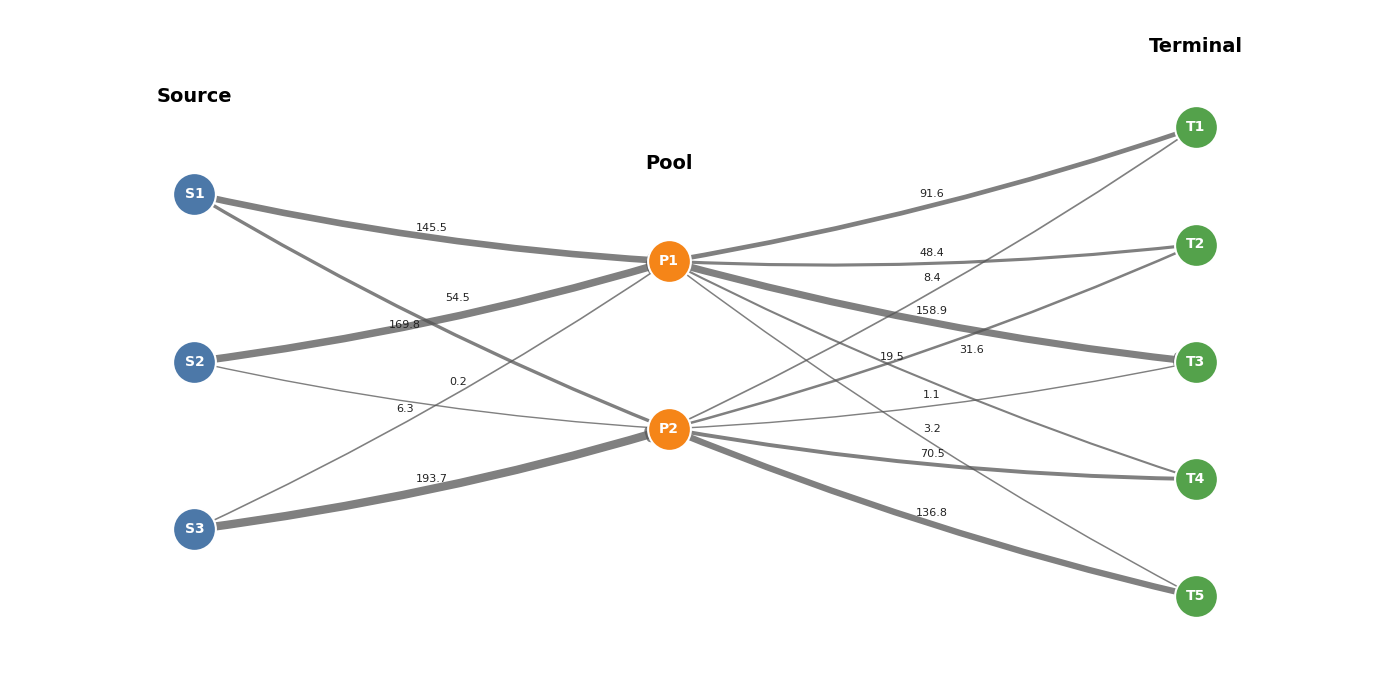

In [32]:
# Plot the Pooling Problem network flow diagram
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

if model_1.status in (COPT.OPTIMAL, COPT.LOCAL_OPTIMAL):
    
    positions = {
        "S1": (0, 2.2), "S2": (0, 1.2), "S3": (0, 0.2),
        "P1": (1.8, 1.8), "P2": (1.8, 0.8),
        "T1": (3.8, 2.6), "T2": (3.8, 1.9), "T3": (3.8, 1.2),
        "T4": (3.8, 0.5), "T5": (3.8, -0.2),
    }
    
    # Manually set small text offsets (dx, dy) for crossing routes that may overlap
    text_offsets = {
        ("S1", "P2"): (0.1, 0.08),   # Slightly adjust upward and to the right
        ("S2", "P1"): (-0.1, -0.08), # Slightly adjust downward and to the left
        ("S2", "P2"): (0.1, 0.08),   
        ("S3", "P1"): (-0.1, -0.08),
        ("P1", "T4"): (-0.15, 0.08),
        ("P2", "T2"): (0.15, -0.08)
    }
    
    colors = {**{s: "#4C78A8" for s in SOURCE}, **{p: "#F58518" for p in POOL}, **{t: "#54A24B" for t in TERMINAL}}
    fig, ax = plt.subplots(figsize=(14, 7))
    
    max_flow = max(flow_value.values()) if flow_value else 1.0
    
    # Draw directed edges
    for (i, j), value in flow_value.items():
        if value <= 1e-6:
            continue
        x1, y1 = positions[i]
        x2, y2 = positions[j]
        arrow = FancyArrowPatch(
            (x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=14,
            linewidth=1.0 + 5.0 * value / max_flow, color="#555555", alpha=0.75,
            connectionstyle="arc3,rad=0.04",
        )
        ax.add_patch(arrow)
        
        # Calculate the original midpoint
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        # Get the offset for this route; use (0, 0) if none is defined
        dx, dy = text_offsets.get((i, j), (0, 0))
        
        # Add the offset and draw centered text
        ax.text(mid_x + dx, mid_y + dy, f"{value:.1f}", fontsize=8, color="#222222", ha="center", va="center")
        
    # Draw nodes
    for node, (x_pos, y_pos) in positions.items():
        ax.scatter(x_pos, y_pos, s=950, color=colors[node], edgecolor="white", linewidth=1.5, zorder=3)
        ax.text(x_pos, y_pos, node, ha="center", va="center", color="white", weight="bold", zorder=4)
        
    # Add labels and title
    ax.text(0, 2.75, "Source", ha="center", fontsize=14, weight="bold")
    ax.text(1.8, 2.35, "Pool", ha="center", fontsize=14, weight="bold")
    ax.text(3.8, 3.05, "Terminal", ha="center", fontsize=14, weight="bold")
    ax.set_xlim(-0.7, 4.5)
    ax.set_ylim(-0.7, 3.3)
    ax.axis("off")
    
    plt.tight_layout()
    plt.show()